# [0.1] DESI Data: Import a Subset


In [2]:
import os
import fitsio
import numpy as np
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits
from astropy.table import join, Table
import pandas as pd
import nested_pandas as npd
import matplotlib.pyplot as plt
import glob
import pyarrow as pa
import lsdb
from hats.io.validation import is_valid_catalog
from hats_import.catalog.file_readers import InputReader
from hats_import.pipeline import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments
from dask.distributed import Client

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
main_directory = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron")
core_redshift_catalog = main_directory / "zcatalog/v1/zall-pix-iron.fits"
spectra_directory = main_directory / "healpix/"

## 00 - Hats import the data (with nested)

**Where will the product live?** 
- Unsure. 
- In my notes' Background section, I mention a USDF dir `/sdf/data/rubin/cosmicdata/lsdb` where we want to "transfer (nearly) all HATS catalogs that are on data.lsdb.io"
- But in Stephen Bailey's email, he mentions two dirs:
    - `/global/cfs/cdirs/cosmo/users/` for testing (make your own user dir here)
    - `/global/cfs/cdirs/cosmo/www/users/` for dir you want to make web visible

Let's target the dir that Stephen talked about, especially for this initial subset. And recall, we have an honor-system imposed 50TB limit here.

In [4]:
users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"
os.makedirs(target_user_dir, exist_ok=True)

! tree -L 2 $users_dir

/global/cfs/cdirs/cosmo/users
├── cosmo
│   ├── archive_unwise_neo11.log
│   └── archive_unwise_neo9.log
├── olynn
│   └── desi-dr1-test
├── sjbailey
│   ├── dev
│   └── git
└── xiangchl
    ├── DP1
    ├── pdr3_dud_rev
    └── pdr3_wide

10 directories, 2 files


In [5]:
# Set up paths and arguments for the HATS import pipeline run.

base_path = spectra_directory
output_path = target_user_dir

print(f"Base path for input files: {base_path}")
print(f"Output path for HATS import: {output_path}")

Base path for input files: /global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix
Output path for HATS import: /global/cfs/cdirs/cosmo/users/olynn


### Test the main read() functionality
Demo the logic we'd like to put into the read method of our custom InputReader

In [6]:
print(spectra_directory)

spectra_file = spectra_directory / "main/dark/0/0/spectra-main-dark-0.fits.gz"
redrock_file = spectra_directory / "main/dark/0/0/redrock-main-dark-0.fits"

/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix


In [7]:
fibermap_columns = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS', 'MJD', 'EXPTIME', 'NIGHT',
]
redrock_columns = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']

with fits.open(spectra_file, memmap=True) as hdul:
    fibermap = Table(hdul['FIBERMAP'].data)[fibermap_columns].to_pandas()

with fits.open(redrock_file, memmap=True) as hdul:
    redshifts = Table(hdul['REDSHIFTS'].data)[redrock_columns].to_pandas()

# join on TARGETID, use TARGETID as index for join_nested alignment
joined = fibermap.merge(redshifts, on='TARGETID', how='left')
joined = npd.NestedFrame(joined.set_index('TARGETID'))

# add one nested column per camera
with fits.open(spectra_file, memmap=True) as hdul:
    for cam in ['B', 'R', 'Z']:
        wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')  # float64, native endian
        flux = hdul[f'{cam}_FLUX'].data.astype('f4')        # float32, native endian
        ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
        mask = hdul[f'{cam}_MASK'].data.astype('i4')        # int32, native endian

        n_wave = len(wave)
        n_targets = len(joined)
        target_ids = joined.index

        flat = pd.DataFrame({
            'wavelength': np.tile(wave, n_targets),
            'flux':       flux.ravel(),
            'ivar':       ivar.ravel(),
            'mask':       mask.ravel(),
        }, index=np.repeat(target_ids, n_wave))

        joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

In [8]:
# Idk if this is because I'm using this notebook by sshing into nersc through my IDE, or it's always like this on NERSC, but the 
# standard display of frames is just plain text and I simply will not stand for that; so, we use .style.format()

joined[:3].style.format()

,TARGET_RA,TARGET_DEC,DESI_TARGET,BGS_TARGET,MWS_TARGET,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,EBV,MORPHTYPE,PHOTSYS,MJD,EXPTIME,NIGHT,Z,ZERR,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,spectra_b,spectra_r,spectra_z
TARGETID,,,,,,,,,,,,,,,,,,,,,,,,,
39627791519454588,44.925441,0.149561,262148,0,0,3.500351,6.499963,8.481231,9.281976,11.241416,0.082197,PSF,S,59495.413593,1191.873900,20211007,0.000010,0.000004,0,3633.518637,STAR,K,wavelength flux ivar mask 0 3600.0 1.739684 0.100833 0 1 3600.8 -2.124764 0.113577 0 ... ... ... ... ... 13753 5799.2 5.070947 2.541216 0 13754 5800.0 4.602400 3.266227 0 [13755 rows x 4 columns],wavelength flux ivar mask 0 5760.0 6.899910 0.232071 0 1 5760.8 2.049876 0.183555 0 ... ... ... ... ... 11628 7619.2 3.505144 0.624296 0 11629 7620.0 6.747208 0.585219 0 [11630 rows x 4 columns],wavelength flux ivar mask 0 7520.0 4.240441 2.411359 0 1 7520.8 5.404689 1.856850 0 ... ... ... ... ... 14403 9823.2 1.659114 15.383480 0 14404 9824.0 2.372234 13.747556 0 [14405 rows x 4 columns]
39627791519452760,44.872364,0.256157,655394,0,0,0.473666,0.693162,1.390630,0.554141,-1.799120,0.083015,REX,S,59495.413593,1191.873900,20211007,0.907971,0.000028,0,393.729365,GALAXY,,wavelength flux ivar mask 0 3600.0 -2.130269 0.113095 0 1 3600.8 4.231301 0.116481 0 ... ... ... ... ... 5500 5799.2 1.135215 1.319445 0 5501 5800.0 -1.144236 1.785819 0 [5502 rows x 4 columns],wavelength flux ivar mask 0 5760.0 1.167899 0.226351 0 1 5760.8 -2.525813 0.190141 0 ... ... ... ... ... 4650 7619.2 1.338428 0.592494 0 4651 7620.0 -1.651159 0.789980 0 [4652 rows x 4 columns],wavelength flux ivar mask 0 7520.0 -0.150412 5.308166 0 1 7520.8 0.855615 3.800079 0 ... ... ... ... ... 5760 9823.2 -0.486063 4.859091 0 5761 9824.0 -0.220673 7.376045 0 [5762 rows x 4 columns]
39627791519456177,44.979791,0.158020,65537,0,0,0.291093,1.602971,8.538551,31.935289,17.992620,0.086307,DEV,S,59495.413593,1191.873900,20211007,0.766289,0.000111,0,428.309324,GALAXY,,wavelength flux ivar mask 0 3600.0 -1.204607 0.111333 0 1 3600.8 -0.958540 0.119109 0 ... ... ... ... ... 5500 5799.2 0.014980 1.352428 0 5501 5800.0 -1.470835 1.881395 0 [5502 rows x 4 columns],wavelength flux ivar mask 0 5760.0 0.924134 0.255891 0 1 5760.8 -1.578270 0.220730 0 ... ... ... ... ... 4650 7619.2 -0.299995 0.455659 0 4651 7620.0 -2.343368 0.000000 1 [4652 rows x 4 columns],wavelength flux ivar mask 0 7520.0 1.506479 5.522980 0 1 7520.8 1.302375 3.915041 0 ... ... ... ... ... 5760 9823.2 0.604918 5.605419 0 5761 9824.0 0.403181 10.207658 0 [5762 rows x 4 columns]


In [9]:
joined['spectra_b'][joined.index[0]]

TARGETID
39627791519454588    [{wavelength: 3600.0, flux: 1.739684, ivar: 0....
39627791519454588    [{wavelength: 3600.0, flux: 1.739684, ivar: 0....
39627791519454588    [{wavelength: 3600.0, flux: 1.739684, ivar: 0....
39627791519454588    [{wavelength: 3600.0, flux: 1.739684, ivar: 0....
39627791519454588    [{wavelength: 3600.0, flux: 1.739684, ivar: 0....
Name: spectra_b, dtype: nested<wavelength: [double], flux: [float], ivar: [float], mask: [int32]>

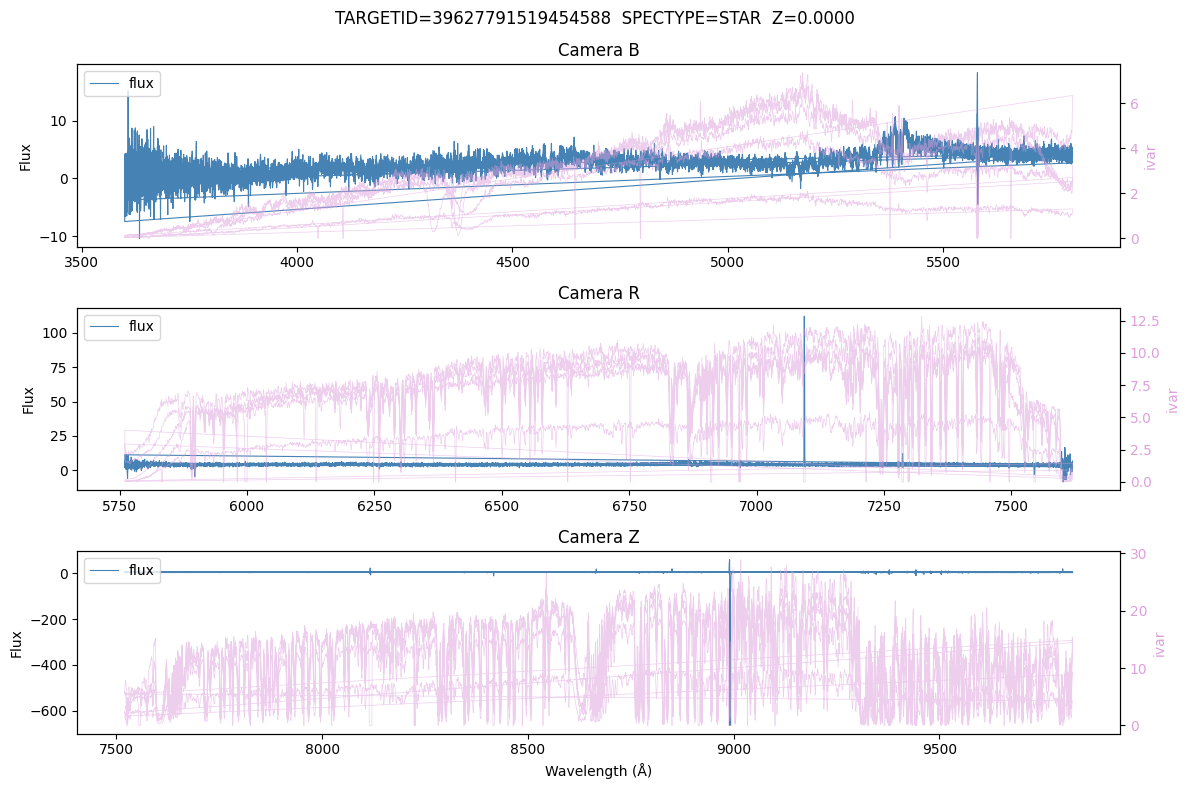

In [10]:
target_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ['steelblue', 'plum']

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ['b', 'r', 'z']):
    # Get the spectrum.
    spec = joined[f'spectra_{cam}'].iloc[target_idx]
    
    # Plot flux on the primary y-axis.
    ax.plot(spec['wavelength'], spec['flux'], lw=0.8, color=colors[0], label='flux')
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec['wavelength'], spec['ivar'], lw=0.5, color=colors[1], alpha=0.5, label='ivar')
    ax_twin.set_ylabel('ivar', color=colors[1])
    ax_twin.tick_params(axis='y', labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel('Flux')
    ax.set_title(f'Camera {cam.upper()}')
    ax.legend(loc='upper left')

# Set x-axis label and overall figure title.
axes[-1].set_xlabel('Wavelength (Å)')
fig.suptitle(f'TARGETID={joined.index[target_idx]}  SPECTYPE={joined["SPECTYPE"].iloc[target_idx]}  Z={joined["Z"].iloc[target_idx]:.4f}')
plt.tight_layout()
plt.show()

### Figure out the lines in the plots!

Let's chunk the df into different colors, we can see how the data's laid out, and when it circles back

n_chunks 14
plotting chunk 0
plotting chunk 1
plotting chunk 2


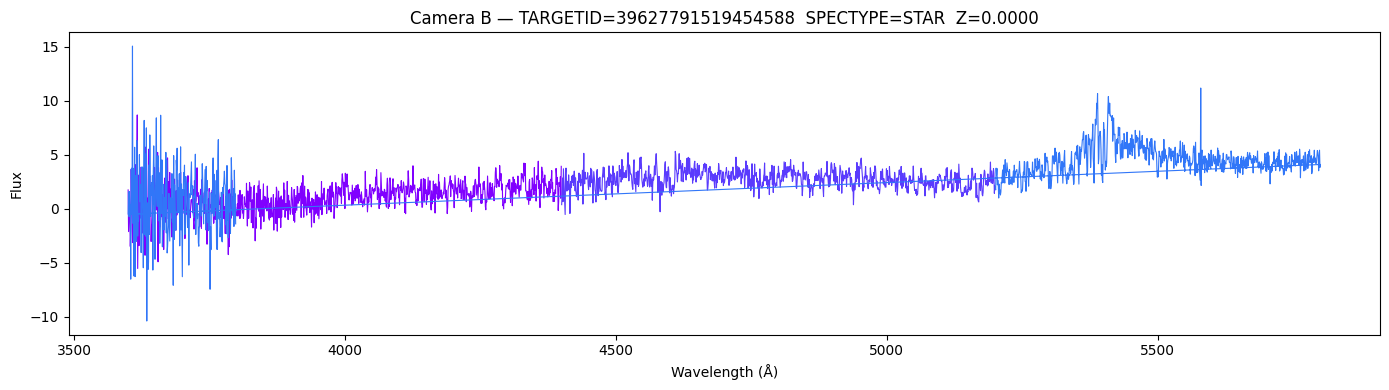

In [11]:
import matplotlib.cm as cm

target_idx = 0
cam = 'b'
spec = joined[f'spectra_{cam}'].iloc[target_idx]

chunk_size = 1000
n_chunks = len(spec) // chunk_size + 1
colors = cm.rainbow(np.linspace(0, 1, n_chunks))

print("n_chunks", n_chunks)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
for i, color in enumerate(colors):
    if i < 3:
        print(f"plotting chunk {i}")
        start = i * chunk_size
        end = min(start + chunk_size, len(spec))
        chunk = spec.iloc[start:end]
        ax.plot(chunk['wavelength'], chunk['flux'], lw=0.8, color=color)

ax.set_ylabel('Flux')
ax.set_xlabel('Wavelength (Å)')
ax.set_title(f'Camera {cam.upper()} — TARGETID={joined.index[target_idx]}  SPECTYPE={joined["SPECTYPE"].iloc[target_idx]}  Z={joined["Z"].iloc[target_idx]:.4f}')
plt.tight_layout()
plt.show()

In [12]:
target_idx = 0
cam = 'b'
spec = joined[f'spectra_{cam}'].iloc[target_idx]

# find indices where wavelength jumps backwards or makes a huge leap
wave = spec['wavelength'].to_numpy()
diffs = np.diff(wave)
jump_indices = np.where(diffs < 0)[0]

print(f"Number of backward jumps: {len(jump_indices)}")
print("Jump locations:")
for idx in jump_indices:
    print(f"  index {idx}: wavelength goes from {wave[idx]:.2f} → {wave[idx+1]:.2f}  (diff={diffs[idx]:.2f})")

Number of backward jumps: 4
Jump locations:
  index 2750: wavelength goes from 5800.00 → 3600.00  (diff=-2200.00)
  index 5501: wavelength goes from 5800.00 → 3600.00  (diff=-2200.00)
  index 8252: wavelength goes from 5800.00 → 3600.00  (diff=-2200.00)
  index 11003: wavelength goes from 5800.00 → 3600.00  (diff=-2200.00)


In [13]:
with fits.open(spectra_file, memmap=True) as hdul:
    wave = hdul['B_WAVELENGTH'].data
    flux = hdul['B_FLUX'].data

print(f"wave shape: {wave.shape}")       # should be (2751,)
print(f"flux shape: {flux.shape}")       # should be (2356, 2751) or (2751, 2356)?
print(f"flux.ravel()[:5]: {flux.ravel()[:5]}")
print(f"flux[0,:5]: {flux[0,:5]}")       # first target, first 5 wavelengths
print(f"flux[:,0][:5]: {flux[:,0][:5]}") # first wavelength, first 5 targets

wave shape: (2751,)
flux shape: (2356, 2751)
flux.ravel()[:5]: [ 1.7396841  -2.1247642  -0.73501915  0.9242405  -0.76886743]
flux[0,:5]: [ 1.7396841  -2.1247642  -0.73501915  0.9242405  -0.76886743]
flux[:,0][:5]: [ 1.7396841  -2.1302693  -1.2046075   0.38469324 -0.6044698 ]


In [14]:
# use the unique TARGETIDs, not joined.index which may have duplicates
target_ids = joined.index.unique()
print(f"joined rows: {len(joined)}")
print(f"unique target ids: {len(target_ids)}")
print(f"flux n_targets: {flux.shape[0]}")

joined rows: 2356
unique target ids: 1704
flux n_targets: 2356


In [15]:
print(f"fibermap rows: {len(fibermap)}")
print(f"unique TARGETIDs in fibermap: {fibermap['TARGETID'].nunique()}")
print(f"example duplicated TARGETID:")
print(fibermap[fibermap.duplicated('TARGETID', keep=False)][['TARGETID']].head(10))

fibermap rows: 2356
unique TARGETIDs in fibermap: 1704
example duplicated TARGETID:
            TARGETID
0  39627791519454588
1  39627791519452760
2  39627791519456177
3  39627785479655815
4  39627791519455650
5  39627791519454413
6  39627791519452686
7          -48140048
8  39627785483846233
9  39627791519456493


In [16]:
coadd_file = str(spectra_file).replace('spectra-', 'coadd-').replace('.fits.gz', '.fits')

with fits.open(coadd_file, memmap=True) as hdul:
    hdul.info()
    coadd_fibermap = Table(hdul['FIBERMAP'].data)
    print(f"\ncoadd fibermap rows: {len(coadd_fibermap)}")
    print(f"unique TARGETIDs: {len(np.unique(coadd_fibermap['TARGETID']))}")

Filename: /global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix/main/dark/0/0/coadd-main-dark-0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     157   ()      
  1  FIBERMAP      1 BinTableHDU    193   1704R x 67C   [K, J, D, D, E, E, E, K, B, 3A, D, J, I, 8A, J, J, 4A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E, E, E, K, 2A, E, E, E, E, 1A, K, K, K, K, K, K, D, D, I, E, I, I, E, E, E, E, D, E, D, E, E]   
  2  EXP_FIBERMAP    1 BinTableHDU     64   2356R x 26C   [K, J, D, J, J, D, J, D, I, J, K, J, J, E, E, E, D, D, K, D, D, D, D, D, D, D]   
  3  B_WAVELENGTH    1 ImageHDU        10   (2751,)   float64   
  4  B_FLUX        1 ImageHDU        11   (2751, 1704)   float32   
  5  B_IVAR        1 ImageHDU        11   (2751, 1704)   float32   
  6  B_MASK        1 ImageHDU        10   (2751, 1704)   int32   
  7  B_RESOLUTION    1 ImageHDU        11   (2751, 11, 1704)   float32   
  8  R_WAVELENGTH    1 ImageHDU 

In [17]:
with fits.open(redrock_file, memmap=True) as hdul:
    print(hdul['EXP_FIBERMAP'].columns)
    exp_fibermap = Table(hdul['EXP_FIBERMAP'].data).to_pandas()
    print(f"\nrows: {len(exp_fibermap)}")
    print(f"unique TARGETIDs: {exp_fibermap['TARGETID'].nunique()}")
    print(exp_fibermap.head())

ColDefs(
    name = 'TARGETID'; format = 'K'
    name = 'PRIORITY'; format = 'J'
    name = 'SUBPRIORITY'; format = 'D'
    name = 'NIGHT'; format = 'J'
    name = 'EXPID'; format = 'J'
    name = 'MJD'; format = 'D'
    name = 'TILEID'; format = 'J'
    name = 'EXPTIME'; format = 'D'
    name = 'PETAL_LOC'; format = 'I'
    name = 'DEVICE_LOC'; format = 'J'
    name = 'LOCATION'; format = 'K'
    name = 'FIBER'; format = 'J'
    name = 'FIBERSTATUS'; format = 'J'
    name = 'FIBERASSIGN_X'; format = 'E'
    name = 'FIBERASSIGN_Y'; format = 'E'
    name = 'LAMBDA_REF'; format = 'E'
    name = 'PLATE_RA'; format = 'D'
    name = 'PLATE_DEC'; format = 'D'
    name = 'NUM_ITER'; format = 'K'
    name = 'FIBER_X'; format = 'D'
    name = 'FIBER_Y'; format = 'D'
    name = 'DELTA_X'; format = 'D'
    name = 'DELTA_Y'; format = 'D'
    name = 'FIBER_RA'; format = 'D'
    name = 'FIBER_DEC'; format = 'D'
    name = 'PSF_TO_FIBER_SPECFLUX'; format = 'D'
)

rows: 2356
unique TARGETIDs: 1704
   

In [18]:
EXP_FIBERMAP_COLUMNS = [
    'TARGETID',
    'NIGHT', 'EXPID', 'MJD', 'EXPTIME', 'TILEID',
    'FIBER', 'FIBERSTATUS',
    'FIBER_RA', 'FIBER_DEC',
    'DELTA_X', 'DELTA_Y',
    'PSF_TO_FIBER_SPECFLUX',
]

<div class="alert alert-info">
<b>ELI5: Inverse Variance</b>

`Inverse variance = 1 / (noise²)`

Think of it as a **confidence score** for each pixel. For each wavelength bin, the detector measured some flux, but that measurement has some uncertainty (noise). Instead of storing the noise directly, DESI stores 1/noise².  

- High ivar → low noise → you can trust this pixel  
- Low ivar → high noise → be skeptical of this pixel  
- ivar = 0 → the pixel is completely bad/masked, don't use it at all  

The reason astronomers use ivar instead of just noise is practical: when you want to combine or fit spectra, the math works out more cleanly with inverse variance. For example, the best estimate of a quantity from noisy data is just a weighted average where the weights are... the inverse variances.  

For DESI specifically you'd expect:  

- Low ivar at the blue edge of B (~3600Å) — detectors are just less sensitive there  
- Low ivar at the red edge of Z (~9800Å) — same reason, plus sky background gets noisy  
- Spikes of ivar=0 scattered throughout — bad pixels, cosmic rays, or bright sky emission lines that got masked  
</div>


### Generalize a tiny bit: run hats-import on 2 fits files
*(Let's show n and n -> n+1)*

Demonstrate we can run this on:
- **group 0 healpix 0**, to show we can run it at all, and
- **group 0 healpix 1**, to show we can run this on more than one input file at a time

In [ ]:
# Import and set up dask

from dask.distributed import Client
import socket

# Make a dask client
client = Client(
    n_workers=4,
    memory_limit="4GB",
)
client


In [ ]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.
username = "olynn"
current_compute_node = socket.gethostname()

print(f"1. In a local terminal, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser at: http://localhost:8787/status")

### Define custom input reader

In [ ]:
FIBERMAP_COLUMNS = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS', 'MJD', 'EXPTIME', 'NIGHT',
]
REDROCK_COLUMNS = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']


class DesiSpectraReader(InputReader):

    def __init__(self, chunksize=500_000):
        self.chunksize = chunksize

    def read(self, input_file, read_columns=None):
        print(f"reading {input_file}") 
        
        # derive redrock path from spectra path
        input_file = str(input_file)  # convert UPath to string first
        redrock_file = input_file.replace('spectra-', 'redrock-').replace('.fits.gz', '.fits')


        # read fibermap
        with fits.open(input_file, memmap=True) as hdul:
            fibermap = Table(hdul['FIBERMAP'].data)[FIBERMAP_COLUMNS].to_pandas()
            # convert to native byte order
            fibermap = fibermap.astype({col: fibermap[col].dtype.newbyteorder('=') 
                                        for col in fibermap.columns})

        # read redshifts
        with fits.open(redrock_file, memmap=True) as hdul:
            redshifts = Table(hdul['REDSHIFTS'].data)[REDROCK_COLUMNS].to_pandas()
            redshifts = redshifts.astype({col: redshifts[col].dtype.newbyteorder('=')
                                          for col in redshifts.columns})

        # join and set TARGETID as index
        joined = fibermap.merge(redshifts, on='TARGETID', how='left')
        joined = npd.NestedFrame(joined.set_index('TARGETID'))

        # add nested spectra columns per camera
        with fits.open(input_file, memmap=True) as hdul:
            for cam in ['B', 'R', 'Z']:
                wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')
                flux = hdul[f'{cam}_FLUX'].data.astype('f4')
                ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
                mask = hdul[f'{cam}_MASK'].data.astype('i4')

                n_wave = len(wave)
                target_ids = joined.index

                flat = pd.DataFrame({
                    'wavelength': np.tile(wave, len(joined)),
                    'flux':       flux.ravel(),
                    'ivar':       ivar.ravel(),
                    'mask':       mask.ravel(),
                }, index=np.repeat(target_ids, n_wave))

                joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

        yield joined
        print(f"yielded {len(joined)} rows")


def get_desi_input_files(base_path, surveys=('main',), programs=('dark',)):
    files = []
    for survey in surveys:
        for program in programs:
            pattern = os.path.join(
                base_path, survey, program, '*', '*',
                f'spectra-{survey}-{program}-*.fits.gz'
            )
            files.extend(glob.glob(pattern))
    return sorted(files)

In [ ]:
### Set up & run pipeline

In [ ]:
# Just healpix group 0, pixels 0 and 1
test_files = [
    f'{base_path}/main/dark/0/0/spectra-main-dark-0.fits.gz',
    f'{base_path}/main/dark/0/1/spectra-main-dark-1.fits.gz',
]

args = ImportArguments(
    input_file_list=test_files,
    file_reader=DesiSpectraReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name='desi-dr1-test',
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False
)

In [ ]:
# Remove any files in the output directory 
! tree $output_path
! printf "\nRemoving files...\n\n"
#! rm -rf $output_path/*
! tree $output_path

In [ ]:
pipeline_with_client(args, client)

### Check the imported catalog

In [ ]:
! tree $output_path

In [ ]:
output_catalog = output_path / "desi-dr1-test"

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

In [ ]:
desi_dr1_test_cat = lsdb.open_catalog(output_catalog)
desi_dr1_test_cat

In [ ]:
# Okay, that's a lot of columns. TODO: specify default columns--in the catalog itself?

desi_dr1_test_cat = lsdb.open_catalog(output_catalog, columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z', 'SPECTYPE', 'spectra_b', 'spectra_r', 'spectra_z'])
desi_dr1_test_cat

In [ ]:
df = desi_dr1_test_cat.head(5)
df

In [ ]:
desi_dr1_test_cat.plot_points()